# 🛠️ Machine Learning From Scratch: Algorithmic Portfolio
### *Implementation of Fundamental Learning Algorithms using Only NumPy*

---

## 📌 Project Overview
This repository serves as a technical showcase of my ability to bridge theoretical machine learning mechanics with raw, efficient code implementation. Rather than relying on abstract high-level APIs, everything in this portfolio was built **from the ground up using mathematics and `NumPy`**.

---

## 🗺️ Portfolio Map & Recommended Progression
*The portfolio covers the following algorithms:*

* **K-Nearest Neighbors (KNN)**
* **Decision Trees**
* **Stochastic Gradient Descent (SGD)**
* **Neural Networks (NN)**
* **PCA and Robust PCA**


In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/Othercomputers/My Laptop/Courses/Portfolio/src')

Mounted at /content/drive


# Setup and Impoting Libraries

In [ ]:
import numpy as np
import sys
import gzip
import pickle
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from kernels import GaussianRBFKernel, LinearKernel, PolynomialKernel

from utils import (
    load_dataset,
    plot_classifier,
    euclidean_dist_squared,
    mode,
    evalModel,
    standardize_cols,
    ensure_1d,
    shortest_dist,
    load_trainval)

from knn import KNN
from decision_tree import DecisionTree
from decision_stump import DecisionStumpEquality, DecisionStumpErrorRate, DecisionStumpInfoGain
from neural_net import NeuralNet

from linear_models import (
    LinearModelMultiOutput,
    MulticlassLinearClassifier,
    LinearModel,
    LinearClassifier,
    KernelClassifier)

from learning_rate_getters import (
    ConstantLR,
    InverseLR,
    InverseSquaredLR,
    InverseSqrtLR)

from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import LabelBinarizer

from fun_obj import (
    LeastSquaresLoss,
    MLPLogisticRegressionLossL2,
    PCAFactorsLoss,
    PCAFeaturesLoss,
    RobustPCAFactorsLoss,
    RobustPCAFeaturesLoss,
    SoftmaxLoss,
    CollaborativeFilteringWLoss,
    CollaborativeFilteringZLoss,
)

from encoders import (
    LinearEncoderGradient,
    PCAEncoder,
    NonLinearEncoderMultiLayer,
)

from optimizers import (
    GradientDescent,
    GradientDescentLineSearch,
    StochasticGradient,
    StochasticGradient,
    GradientDescent
)

plt.rcParams["figure.figsize"] = (7, 5)

/tmp/ipykernel_5261/3909968271.py:44: DeprecationWarning: The numpy.linalg.linalg has been made private and renamed to numpy.linalg._linalg. All public functions exported by it are available from numpy.linalg. Please use numpy.linalg.norm instead.
  from fun_obj import (


---

# 📍 1. K-Nearest Neighbors (KNN)

## 📝 1. Algorithmic Description
* **Objective:** Solve non-parametric classification tasks by estimating localized probability densities based on geometric proximity in feature space.
* **Core Mechanics:** This model performs instance-based learning (lazy learning) by bypassing an explicit training phase. For any unseen query point, it computes the pairwise mathematical distance across all instances in the training matrix, identifies the closest $k$ neighbors, and assigns the target label using a localized plurality vote (mode).

## 🏗️ 2. Structural Summary (What I Built)
* **Classes & Modules Implemented:**
  * `KNN` (via `knn.py`): The standalone model class housing the `.fit()` memory storage, neighbor indexing query logic, and consensus voting mechanisms.
  * `utils.py`: Custom mathematical backend utilities handling performance-optimized vector transformations, including `euclidean_dist_squared()` and `mode()`.
* **Loss Functions / Selection Criteria:** Plurality voting consensus via a custom mode selection function. Model validation and selection are measured via classification error rates:
$$\text{Error Rate} = \frac{1}{N}\sum_{i=1}^{N}\mathbb{I}(y_i \neq \hat{y}_i)$$
* **Key Hyperparameters Engineered:** * $k$ (Number of Neighbors): Governs the bias-variance tradeoff, controlling model smoothness and boundary regularization.
  * 10-Fold Cross-Validation Matrix Split: A from-scratch framework to partition data into 10 disjoint subsets, enabling robust hyperparameter selection without relying on high-level wrappers like `scikit-learn`.

## 📊 3. Dataset
* **Dataset Profiles & Public Source Links:**
  * **`citiesSmall.pkl`:** Contains spatial data for 400 US cities across 2 geographical features (longitude and latitude) to predict binary political alignment targets ($y \in \{0, 1\}$).
    * 🌐 **Public Dataset Access:** [SimpleMaps US Cities Database](https://simplemaps.com/data/us-cities)
  * **`ccdebt.pkl`:** A high-dimensional financial dataset containing 2,000 observations and 91 demographic features used to predict consumer credit behavior.
    * 🌐 **Public Dataset Access:** [Statistics Canada Open Government Portal - Survey of Financial Security Microdata](https://open.canada.ca/data/en/dataset/11aecdcb-8bec-4dbe-9da2-3b0cc4e740c9)

---

### 1.1 Data Ingestion and Shape Verification
Loading the datasets to verify operational dimensions. This initial step ensures matrix compatibility for upstream vector operations.

In [ ]:
dataset = load_dataset("citiesSmall.pkl")
X = dataset["X"]
print(f"The shape of features in citiesSmall is {X.shape}")


dataset = load_dataset("ccdebt.pkl")
X = dataset["X"]
print(f"The shape of features in ccdebt is {X.shape}")

The shape of features in citiesSmall is (400, 2)
The shape of features in ccdebt is (2000, 91)


### 1.2 Core Vectorized Inference Engine
Implementing the non-parametric inference loop. Pairwise distance arrays are computed via vectorized operations before extracting the $k$-closest indexes to calculate localized plurality consensus.

In [ ]:
def predict(self, X_hat):
    t = X_hat.shape[0]
    y_hat = np.zeros(t)

    # Compute squared Euclidean distances between X_hat and training data X
    D_squared = euclidean_dist_squared(X_hat, self.X)

    # Find the indices of the k nearest neighbors
    neigh_idx = D_squared.argsort(axis=1)[:, :self.k]

    for i in range(t):
        # Use mode to handle ties
        y_hat[i] = mode(self.y[neigh_idx[i,:]])

    return y_hat

### 1.3 Parametric Evaluation over Hyperparameter Space
Evaluating model validation risks across sequential step values of $k$ to track empirical generalization performance.

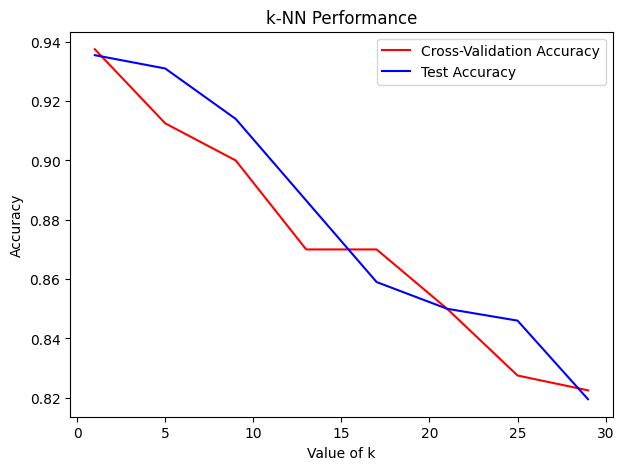

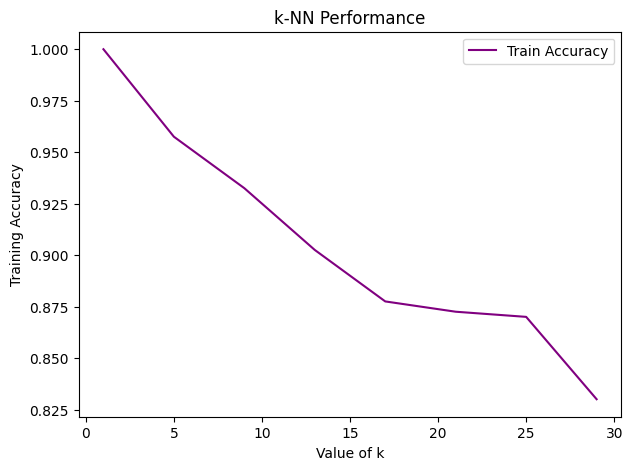

In [ ]:
def accuracy_vs_k():
    dataset = load_dataset("citiesSmall.pkl")
    X = dataset["X"]
    y = dataset["y"]
    X_test = dataset["Xtest"]
    y_test = dataset["ytest"]
    n,d = X.shape
    ks = list(range(1, 30, 4))
    fold_n = 10
    fold_size = n//fold_n
    accuracy = np.zeros((fold_n, len(ks)))
    test_accs = np.zeros(len(ks))
    train_accs = np.zeros(len(ks))

    for k_idx in range(len(ks)):
        for fold_idx in range(10):
            mask = np.ones(n, dtype=bool)   # reset mask
            mask [fold_idx*fold_size:(fold_idx+1)*fold_size] = False
            X_fold_train = X[mask,:]
            y_fold_train = y[mask]
            X_fold_test = X[~mask,:]
            y_fold_test = y[~mask]
            knn = KNN(ks[k_idx])
            knn.fit(X_fold_train,y_fold_train)
            y_fold_hat = knn.predict(X_fold_test)
            accuracy[fold_idx, k_idx] = np.mean(y_fold_hat == y_fold_test)
        knn = KNN(ks[k_idx])
        knn.fit(X,y)
        y_hat = knn.predict(X_test)
        y_hat_train = knn.predict(X)
        test_accs[k_idx] = np.mean(y_hat == y_test)
        train_accs[k_idx] = np.mean(y_hat_train == y)
            ## accuracy is a matrix with columns be each k (for KNN) and the rows are each fold (10-fold)
    cv_accs =  np.mean(accuracy, axis = 0)
    plt.plot(ks, cv_accs, linestyle = '-', color = 'red', label='Cross-Validation Accuracy')
    plt.plot(ks, test_accs, linestyle = '-', color = 'blue', label='Test Accuracy')
    plt.xlabel("Value of k")
    plt.ylabel("Accuracy")
    plt.title("k-NN Performance")
    plt.legend()
    plt.show()


    plt.plot(ks, train_accs, linestyle = '-', color = 'purple', label='Train Accuracy')
    plt.xlabel("Value of k")
    plt.ylabel("Training Accuracy")
    plt.title("k-NN Performance")
    plt.legend()
    plt.show()

accuracy_vs_k()


### 1.4 Algorithmic Benchmarking: Instance-Based vs. Axis-Aligned Selection
Comparing instance-based distance structures against an axis-aligned recursive `DecisionTree` (depth=5) baseline to evaluate model suitability on continuous spatial topologies.

| Model | Training Error (%) | Test Error (%) |
| :--- | :--- | :--- |
| kNN (k=1) | 0.0 | 6.5 |
| kNN (k=3) | 2.8 | 6.6 |
| kNN (k=10) | 5.8 | 8.5 |
| Decision Tree (depth=5) | 10.8 | 16.1 |


In [ ]:
def knn_vs_tree():
    dataset = load_dataset("citiesSmall.pkl")
    X = dataset["X"]
    y = dataset["y"]
    X_test = dataset["Xtest"]
    y_test = dataset["ytest"]

    tree = DecisionTree(5)
    tree.fit(X,y)
    y_hat_tree_train = tree.predict(X)
    error_tree_train = 1- np.mean(y_hat_tree_train == y)
    y_hat_tree_test = tree.predict(X_test)
    error_tree_test = 1- np.mean(y_hat_tree_test == y_test)
    print(f"The training error for tree with maximum depth of 5 is {np.round(error_tree_train,4)*100:.1f}%")
    print(f"The testing error for tree with maximum depth of 5 is {np.round(error_tree_test,4)*100:.1f}%")

knn_vs_tree()

The training error for tree with maximum depth of 5 is 10.8%
The testing error for tree with maximum depth of 5 is 16.1%


Visualizing Decision Boundary for k=1...


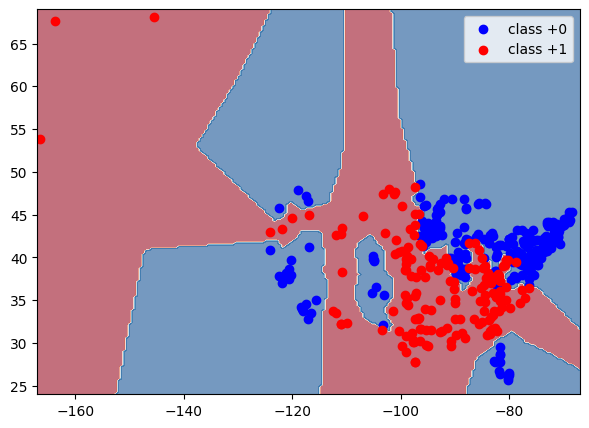

In [ ]:
dataset = load_dataset("citiesSmall.pkl")
X, y = dataset["X"], dataset["y"]

model = KNN(k=1)
model.fit(X, y)

print("Visualizing Decision Boundary for k=1...")
plot_classifier(model, X, y)
# plt.title("kNN Decision Boundary (k=1)")
# plt.show()

### 1.5 Out-of-Sample Validation via From-Scratch 10-Fold CV
Implementing a manual data partitioning framework to evaluate unbiased validation errors, eliminating potential target leakage without relying on external libraries.

In [ ]:
def cross_validate_knn():
    dataset = load_dataset("ccdebt.pkl")
    X, y = dataset["X"], dataset["y"]
    n, d = X.shape
    ks = list(range(1, 30, 4))
    fold_n = 10
    fold_size = n // fold_n

    accuracy = np.zeros((fold_n, len(ks)))

    for k_idx, k in enumerate(ks):
        for fold in range(fold_n):
            mask = np.ones(n, dtype=bool)
            mask[fold*fold_size : (fold+1)*fold_size] = False

            X_train, y_train = X[mask], y[mask]
            X_val, y_val = X[~mask], y[~mask]

            knn = KNN(k)
            knn.fit(X_train, y_train)
            y_pred = knn.predict(X_val)
            accuracy[fold, k_idx] = np.mean(y_pred == y_val)

    cv_accs = np.mean(accuracy, axis=0)
    return ks, cv_accs

ks, cv_accs = cross_validate_knn()
print(f"Best k found by CV: {ks[np.argmax(cv_accs)]}")

Best k found by CV: 17


### 1.6 Empirical Bias-Variance Optimization Profile
Plotting cross-validation outcomes against test accuracies to map out performance limits and isolate structural overfitting risks at localized hyperparameter extremes ($k=1$).

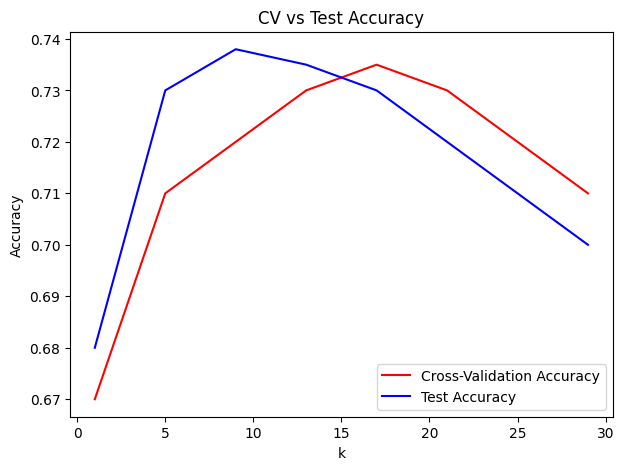

In [ ]:
# Results summarized
train_errs = [0.0, 0.16, 0.19, 0.21, 0.22, 0.23, 0.24, 0.25]
cv_accs = [0.67, 0.71, 0.72, 0.73, 0.735, 0.73, 0.72, 0.71]
test_accs = [0.68, 0.73, 0.738, 0.735, 0.73, 0.72, 0.71, 0.70]

plt.plot(ks, cv_accs, label="Cross-Validation Accuracy", color='red')
plt.plot(ks, test_accs, label="Test Accuracy", color='blue')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CV vs Test Accuracy")
plt.show()

---

# 🌲 2. Decision Trees

## 📝 1. Algorithmic Description
It recursively partitions data by executing greedy feature selection. At each internal node, the algorithm evaluates every available feature split to maximize a purity metric. Once an optimal threshold is identified, the dataset is bisected until either maximum tree depth limits or complete subset purity benchmarks are satisfied.

## 🏗️ 2. Structural Summary (What I Built)
* **Classes & Modules Implemented:**
  * `DecisionStumpEquality`: A baseline foundational stump that splits data using discrete binary feature equality matching.
  * `DecisionStumpErrorRate`: A learning baseline that selects features and split thresholds by directly minimizing empirical classification error.
  * `DecisionStumpInfoGain`: An optimized internal splitter that leverages information theory to evaluate continuous split thresholds.
  * `DecisionTree` (via `decision_tree.py`): The main multi-depth recursive tree engine executing the greedy partition loop, maintaining state tracking for child nodes, internal feature splits, and terminal leaf assignments.
* **Loss Functions / Selection Criteria:** Multi-class performance split dynamics are optimized using Shannon Entropy reduction to calculate Information Gain:
$$\text{Entropy}(D) = -\sum_{i=1}^{C} p_i \log_2(p_i)$$
$$\text{Information Gain} = \text{Entropy}(D_{\text{parent}}) - \sum_{v \in \{\text{left, right}\}} \frac{|D_v|}{|D_{\text{parent}}|} \text{Entropy}(D_v)$$
* **Key Hyperparameters Engineered:**
  * `max_depth`: A strict programmatic ceiling limiting tree expansion to control structural variance and suppress deeper node branching over small noise sample regions.

## 📊 3. Dataset & Empirical Evaluation
* **Dataset Profiles & Public Source Links:**
  * **`citiesSmall.pkl`:** Spatial continuous coordinate attributes mapping 400 US cities across 2 unique geometric metrics (longitude and latitude) to categorize localized political alignment ($y \in \{0, 1\}$).
    * 🌐 **Public Dataset Access:** [SimpleMaps US Cities Database](https://simplemaps.com/data/us-cities)

---

### 2.1. Data Ingestion and Shape Verification
Loading the datasets to verify operational dimensions. This initial step ensures matrix compatibility for upstream vector operations.

X shape: (400, 2)
y shape: (400,)
Class balance: {np.uint8(0): 234, np.uint8(1): 166}


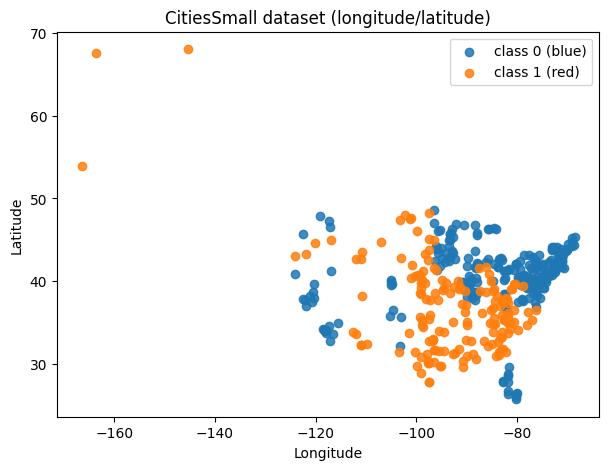

In [ ]:
dataset = load_dataset("citiesSmall.pkl")
X = dataset["X"]
y = dataset["y"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class balance:", {c: int((y==c).sum()) for c in np.unique(y)})

plt.figure()
plt.scatter(X[y==0, 0], X[y==0, 1], label="class 0 (blue)", alpha=0.85)
plt.scatter(X[y==1, 0], X[y==1, 1], label="class 1 (red)", alpha=0.85)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.title("CitiesSmall dataset (longitude/latitude)")
plt.show()

### 2.2 Baseline Formulation: Zero-Information Naive Predictor
Establishing an empirical lower performance bound by implementing a majority-class mode estimator to verify the minimum accuracy thresholds any learned splitting rule must surpass.

In [ ]:
y_pred_majority = np.zeros_like(y) + mode(y)
baseline_error = np.mean(y_pred_majority != y)
print(f"Majority-class training error: {baseline_error:.3f}")

Majority-class training error: 0.415


### 2.3 Baseline Stump Performance: Discretized Categorical Equality Fitting
Evaluating an initial structural baseline that discretizes feature continuous values into categorical intervals using equality matching criteria ($X_{i,j} \approx t$).

Evaluating model: DecisionStumpEquality
Error: 0.380


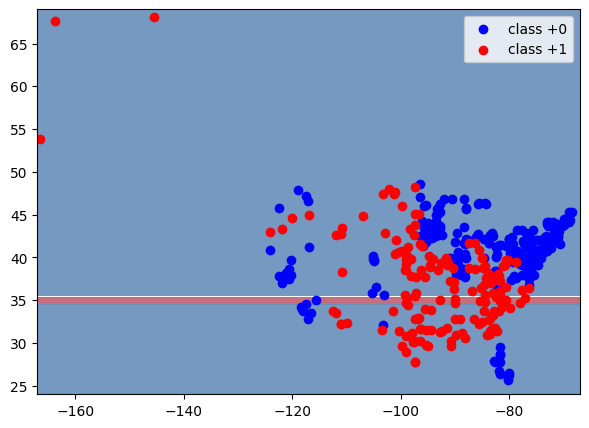

In [ ]:
evalModel(DecisionStumpEquality, X, y)
plt.show()

### 2.4 Empirical Error-Rate Minimizing Split Search
Executing an exhaustive threshold-search optimization ($O(n^2d)$ complexity) that evaluates binary conditional branch candidates ($X_{i,j} > t$) to identify splitting hyperplanes that directly minimize raw misclassification counts.

Evaluating model: DecisionStumpErrorRate
Error: 0.253


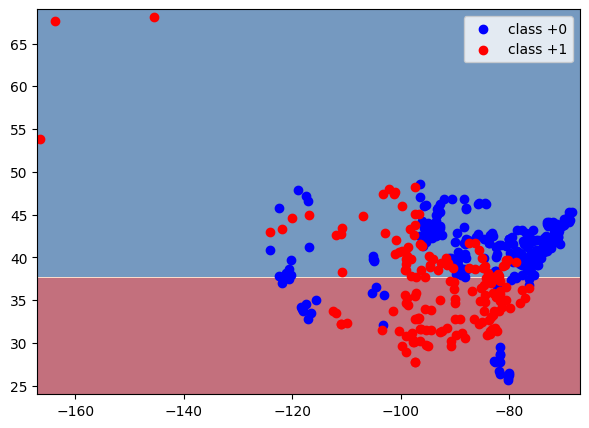

In [ ]:
evalModel(DecisionStumpErrorRate, X, y)
plt.show()

### 2.5 Information-Theoretic Split Search via Shannon Entropy
Optimizing continuous split thresholds by maximizing mathematical Information Gain. This approach utilizes multi-class probability vectors to compute changes in localized parent-child entropy spaces.

Evaluating model: DecisionStumpInfoGain
Error: 0.325


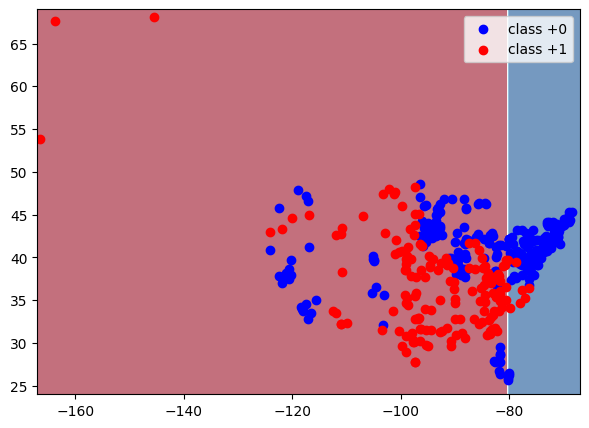

In [ ]:
evalModel(DecisionStumpInfoGain, X, y)
plt.show()

### 2.6 Deep Structural Expansion: Greedy Multi-Depth Tree Recursion
Constructing multi-level decision architectures by cascading individual optimized splitting objects. This function recursively partitions downstream data subsets until bounding depth thresholds or structural limits are satisfied.

DecisionTree depth=2, stump=DecisionStumpInfoGain => train error 0.242


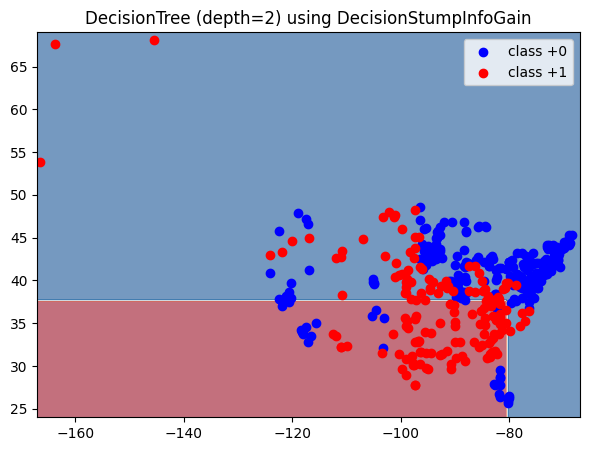

In [ ]:
def fit_tree_and_plot(max_depth, stump_class):
    model = DecisionTree(max_depth=max_depth, stump_class=stump_class)
    model.fit(X, y)
    y_pred = model.predict(X)
    err = np.mean(y_pred != y)
    print(f"DecisionTree depth={max_depth}, stump={stump_class.__name__} => train error {err:.3f}")
    plot_classifier(model, X, y)
    plt.title(f"DecisionTree (depth={max_depth}) using {stump_class.__name__}")
    plt.show()
    return model, err

tree2_infogain, err2 = fit_tree_and_plot(max_depth=2, stump_class=DecisionStumpInfoGain)

### 2.7 Correctness Audit and Convergence Speed Benchmarking
Comparing training loss curves and convergence behavior across scaling tree depths against `scikit-learn`'s production implementation to validate algorithmic consistency and contrast optimization speed limits.

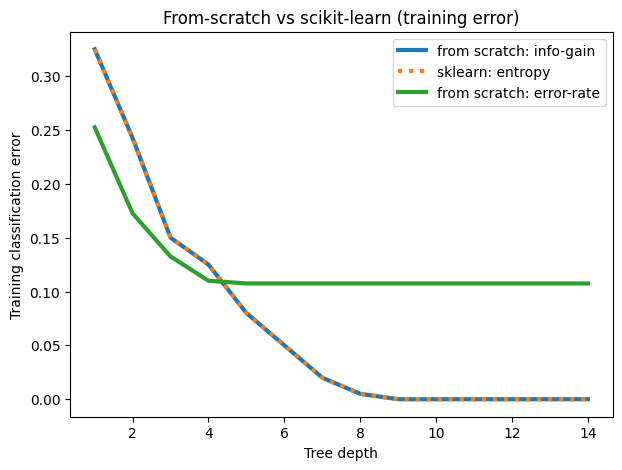

In [ ]:
from sklearn.tree import DecisionTreeClassifier
depths = np.arange(1, 15)

err_errorrate = []
err_infogain = []

for depth in depths:
    m1 = DecisionTree(max_depth=depth, stump_class=DecisionStumpErrorRate)
    m1.fit(X, y)
    err_errorrate.append(np.mean(m1.predict(X) != y))

    m2 = DecisionTree(max_depth=depth, stump_class=DecisionStumpInfoGain)
    m2.fit(X, y)
    err_infogain.append(np.mean(m2.predict(X) != y))

sk_err = []
for depth in depths:
    sk = DecisionTreeClassifier(max_depth=int(depth), criterion="entropy", random_state=1)
    sk.fit(X, y)
    sk_err.append(np.mean(sk.predict(X) != y))

plt.figure()
plt.plot(depths, err_infogain, label="from scratch: info-gain", linewidth=3)
plt.plot(depths, sk_err, label="sklearn: entropy", linestyle=":", linewidth=3)
plt.plot(depths, err_errorrate, label="from scratch: error-rate", linewidth=3)
plt.xlabel("Tree depth")
plt.ylabel("Training classification error")
plt.legend()
plt.title("From-scratch vs scikit-learn (training error)")
plt.show()

---

# 📉 3. Stochastic Gradient Descent (SGD) & Optimization Engines

## 📝 1. Algorithmic Description
 It explores foundational mathematical optimization. It transitions from traditional batch Gradient Descent (which evaluates the complete Jacobian matrix over the entire dataset) to Backtracking Line Search for step-size automation, and ultimately to mini-batch Stochastic Gradient Descent (SGD). SGD approximates the true gradient by computing losses over random, highly compressed data slices, dramatically accelerating convergence on large-scale parameter terrains.

## 🏗️ 2. Structural Summary (What I Built)
* **Classes & Modules Implemented:**
  * `GradientDescent`: A standard batch-wise optimization loop processing full matrix gradients.
  * `GradientDescentLineSearch`: An adaptive optimization engine using Armijo-style line search criteria to dynamically compute step sizes.
  * `StochasticGradient`: A high-throughput optimization engine that partitions data arrays into randomized mini-batches.
  * `ConstantLR`, `InverseLR`, `InverseSqrtLR`: Object-oriented learning rate schedulers implementing custom mathematical step decay over training epochs.
* **Loss Functions / Selection Criteria:** Designed to optimize any differentiable objective function by tracking gradient norms ($||\nabla f(w)||_2$) and loss trajectories across iterations.
* **Key Hyperparameters Engineered:**
  * `batch_size`: Controls the memory footprint and gradient variance profile.
  * Learning Rate Schedulers: Adjusts steps according to $\alpha_t = \frac{\alpha_0}{1 + \gamma t}$ or $\alpha_t = \frac{\alpha_0}{\sqrt{t}}$ to mathematically guarantee convergence under stochastic conditions.

## 📊 3. Dataset & Empirical Evaluation
* **Dataset Profiles:** Continuous or discrete multi-dimensional matrices mapped against target loss landscapes to benchmark optimization trajectories, convergence efficiency, and computational stability.

---

### 3.1 Batch Gradient Descent Implementation
Constructing the foundational optimization loop. This engine updates model weights by calculating the complete gradient across the full input matrix at each iteration step.

### A. Constant Learning Rate ($\alpha^t = c$)
Without a mechanism to "slow down," the model descends rapidly but then bounces around the minimum indefinitely due to stochastic noise. It never truly settles.


### B. Inverse Learning Rate ($\alpha^t = c/t$)
This decays the step size very aggressively. The model often stops moving too early, getting "stuck" far from the global minimum as updates become infinitesimally small.


### C. Inverse Squared Learning Rate ($\alpha^t = c/t^2$)
The most extreme decay. The step size reduces so drastically that the parameters "freeze" almost immediately, leaving the objective function at a very high value.


### D. Inverse Square Root Learning Rate ($\alpha^t = c/\sqrt{t}$)
Strikes the **optimal balance**. It decays slowly enough to explore the parameter space but fast enough to dampen noise, allowing the model to settle into the global minimum (~700).

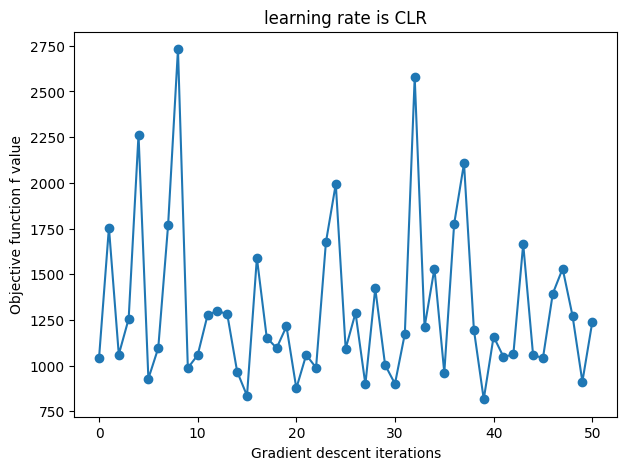

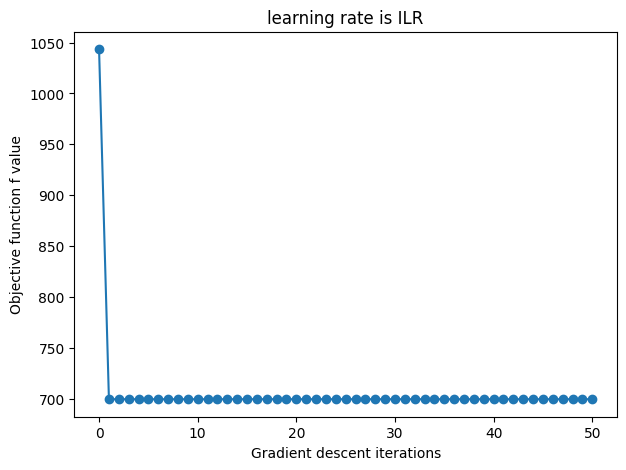

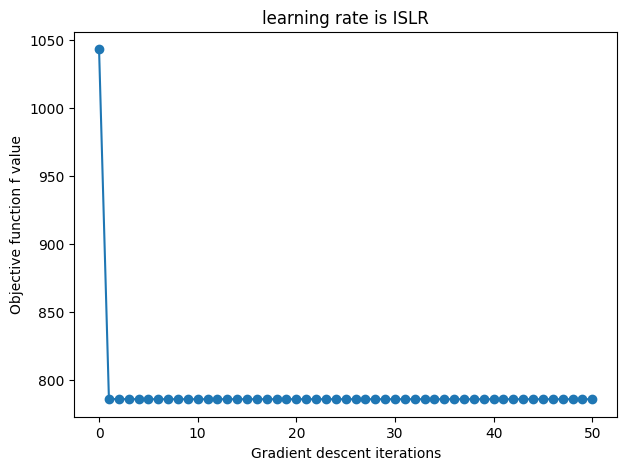

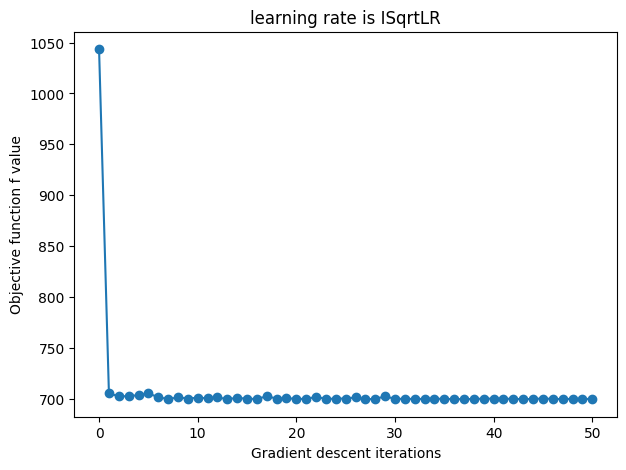

In [ ]:
X_train_orig, y_train, X_val_orig, y_val = load_trainval("dynamics.pkl")
X_train, mu, sigma = standardize_cols(X_train_orig)
X_val, _, _ = standardize_cols(X_val_orig, mu, sigma)

loss = LeastSquaresLoss()
c= 0.1
learning_rate_CLR = ConstantLR(c)
learning_rate_ILR = InverseLR(c)
learning_rate_ISLR = InverseSquaredLR(c)
learning_rate_ISqrtLR = InverseSqrtLR(c)

for (learning_rate, names) in [(learning_rate_CLR,"CLR"),
                                (learning_rate_ILR, "ILR"),
                                (learning_rate_ISLR, "ISLR"),
                                (learning_rate_ISqrtLR, "ISqrtLR")]:
    optimizer = StochasticGradient (learning_rate_getter=learning_rate,
                                batch_size=10,
                                base_optimizer=GradientDescent(),
                                max_evals= 50)
    model  = LinearModel(loss, optimizer)
    model.fit(X_train, y_train)
    fig, ax = plt.subplots()
    ax.plot(model.fs, marker="o")
    ax.set_xlabel("Gradient descent iterations")
    ax.set_ylabel("Objective function f value")
    ax.set_title(f"learning rate is {names}")
    plt.show(fig)

---

# 🧠 Neural Networks From Scratch

## 📝 1. Algorithmic Description
 It represents a complete deep learning workflow engineered natively in NumPy. Data is passed through forward matrix transformations consisting of weight multiplications and non-linear activation functions (Sigmoid). Errors are evaluated at the terminal layer and analytical gradients are propagated backward through the computational graph using the chain rule (backpropagation) to systematically update weights.

## 🏗️ 2. Structural Summary (What I Built)
* **Classes & Modules Implemented:**
  * `LinearModelMultiOutput`: A modular, multi-output linear dense layer executing basic affine transformations ($\mathbf{Z} = \mathbf{X}\mathbf{W} + \mathbf{b}$).
  * `NonLinearEncoderMultiLayer`: A deep feature extractor stacking multiple non-linear hidden layers to transform features into a latent representation space.
  * `MLPLogisticRegressionLossL2`: A unified network container managing cross-entropy operations coupled with an $L_2$ weight regularization penalty (weight decay) to prevent overfitting.
* **Loss Functions / Selection Criteria:** Multi-class classification optimization utilizing regularized cross-entropy loss coupled with an $L_2$ ridge penalty:
$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^N \sum_{k=1}^K y_{ik} \log(\hat{y}_{ik}) + \frac{\lambda}{2} \sum_{l} \|\mathbf{W}_l\|_F^2$$
* **Key Hyperparameters Engineered:**
  * `hidden_layer_sizes`: A list detailing the architectural topology (width and depth) of the hidden layers.
  * `lammy` ($\lambda$): The regularization coefficient controlling structural complexity and scaling back parameter magnitudes.

## 📊 3. Dataset & Empirical Evaluation
* **Dataset Profiles:**
  * **MNIST Subset / Image Pixels:** Grayscale handwritten digit data downsampled into flattened pixel intensity vector arrays.
  * **Sinusoidal/Non-Convex Benchmarks:** Synthetically generated target mappings used to stress-test representation boundaries under intense non-linear requirements.
---

## 4.1. Neural Networks by Hand
I verified the forward pass logic of a single hidden layer network with sigmoid activations ($h(z) = \frac{1}{1+e^{-z}}$).

**Input ParametersWeights**

* ($W$): $\begin{bmatrix} -2 & -1 & 3 \\ 1 & 0 & -2 \end{bmatrix}$

* Output Weights ($v$): $\begin{bmatrix} 4 \\ 2 \end{bmatrix}$

* Example ($x_i$): $\begin{bmatrix} 4 \\ -2 \\ 2 \end{bmatrix}$

### Step-by-Step Execution

1. Hidden Layer Input ($z_i$): $W x_i = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$
2. Activation ($h(z_i)$): Applying sigmoid to the zeros results in $\begin{bmatrix} 0.5 \\ 0.5 \end{bmatrix}$
3. Final Prediction ($\hat{y}_i$): $v^T h(z_i) = (4 \times 0.5) + (2 \times 0.5) = 3$2)

### 4.2. Deep Architecture Compilation: Multi-Layer Non-Linear Encoder
Constructing the deep network architecture. This object links sequential linear layers and interlaces them with element-wise non-linear activation bounds to form a forward computational graph.

In [ ]:
with gzip.open(Path("..", "data", "mnist.pkl.gz"), "rb") as f:
    train_set, valid_set, test_set = pickle.load(f, encoding="latin1")

# Use these y-values for softmax classifier
X_train, y_train = train_set
X_valid, y_valid = valid_set


mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0) + 1e-8   # avoid division by zero

X_train = (X_train - mu) / sigma
X_valid = (X_valid - mu) / sigma

# Use these for training our MLP classifier
binarizer = LabelBinarizer()
Y_train = binarizer.fit_transform(y_train)

n, d = X_train.shape
_, k = Y_train.shape  # k is the number of classes


# Assemble a neural network
# put hidden layer dimensions to increase the number of layers in encoder
hidden_feature_dims = [128, 64]
output_dim = 10

# First, initialize an encoder and a predictor
layer_sizes = [d, *hidden_feature_dims, output_dim]
encoder = NonLinearEncoderMultiLayer(layer_sizes)
predictor = LinearModelMultiOutput(output_dim, k)

# Function object will associate the encoder and the predictor during training
fun_obj = MLPLogisticRegressionLossL2(encoder, predictor, .1)

# Choose optimization strategy
child_optimizer = GradientDescent()
learning_rate_getter = ConstantLR(1e-3)
#learning_rate_getter = InverseSqrtLR (1e-1)
optimizer = StochasticGradient(
    child_optimizer,
    learning_rate_getter,
    500,
    max_evals=20
)

# Assemble!
model = NeuralNet(fun_obj, optimizer, encoder, predictor, classifier_yes=True)

t = time.time()
model.fit(X_train, Y_train)
print("Fitting took {:f} seconds".format((time.time() - t)))

# Compute training error
y_hat = model.predict(X_train)
err_train = np.mean(y_hat != y_train)
print("Training error = ", err_train)

# Compute validation error
y_hat = model.predict(X_valid)
err_valid = np.mean(y_hat != y_valid)
print("Validation error     = ", err_valid)

# Training error =  0.03382
# Validation error     =  0.0507

Fitting took 121.493443 seconds
Training error =  0.03492
Validation error     =  0.0507


### 2) Neural Disentangling
We compare the perofrmace of 4-dimensional hidden features with 2-dimensional hidden features for classifiying a sinusoidal data.


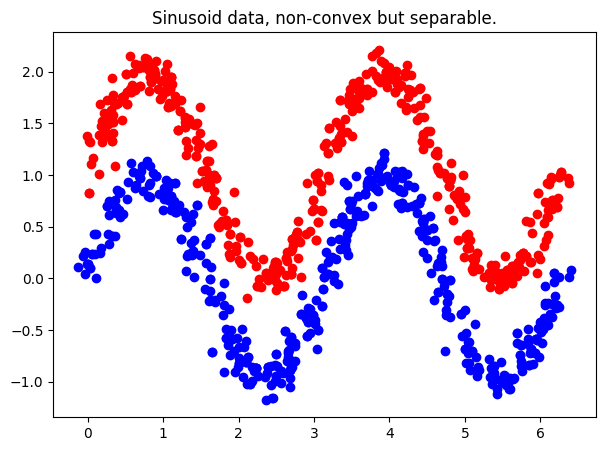


Running with hidden dimensions=[4], output dimension=2


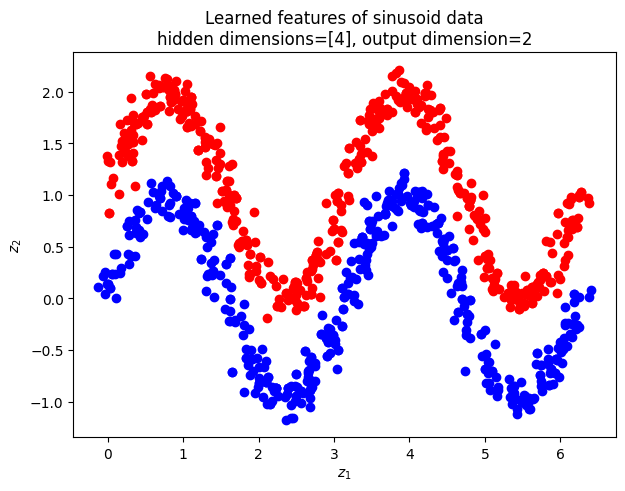

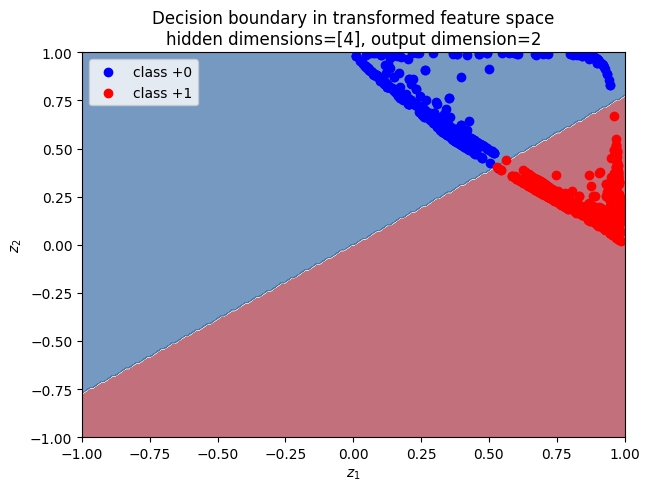

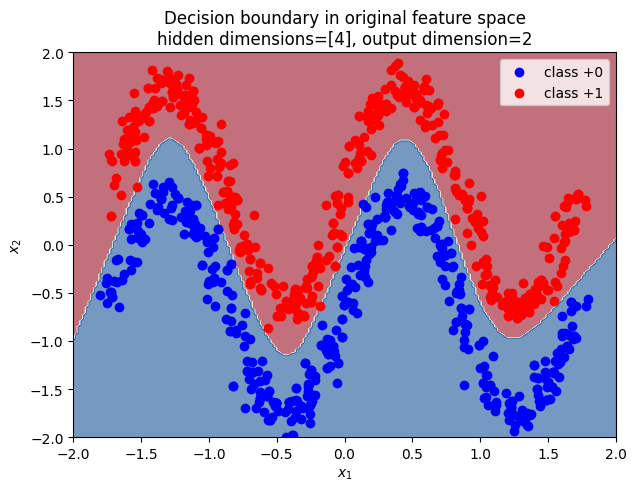


Running with hidden dimensions=[2], output dimension=2


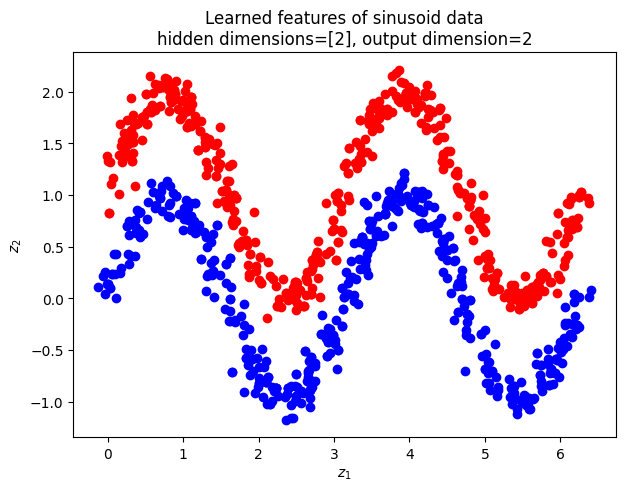

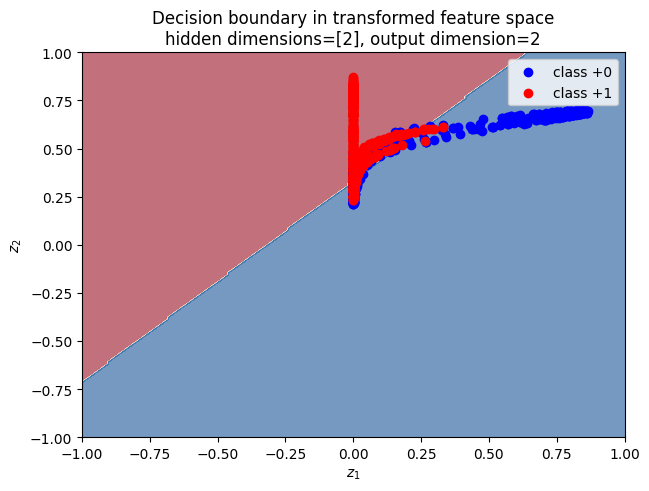

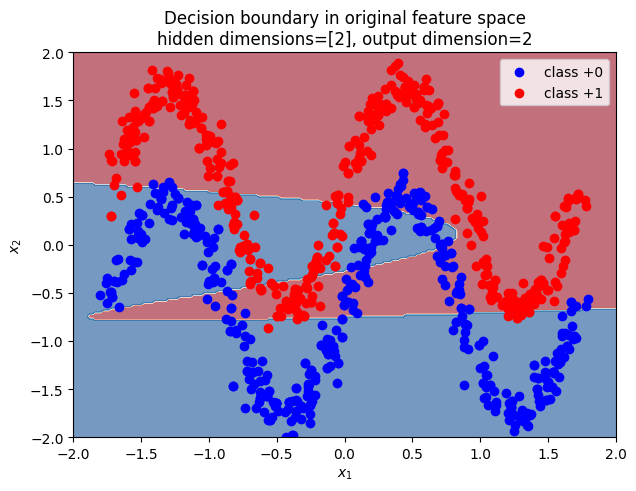


Running with hidden dimensions=[2, 2], output dimension=2


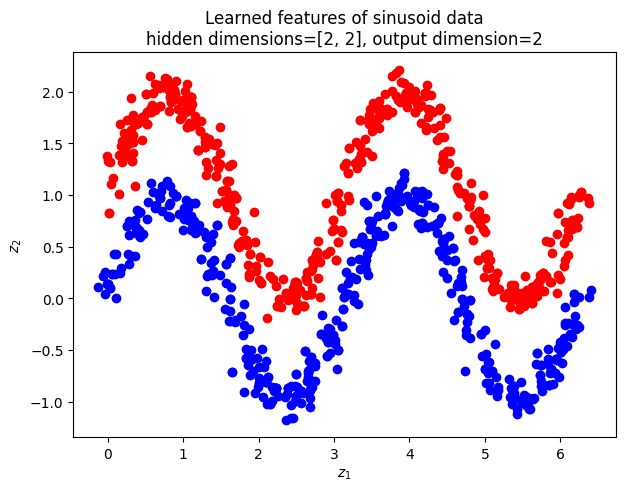

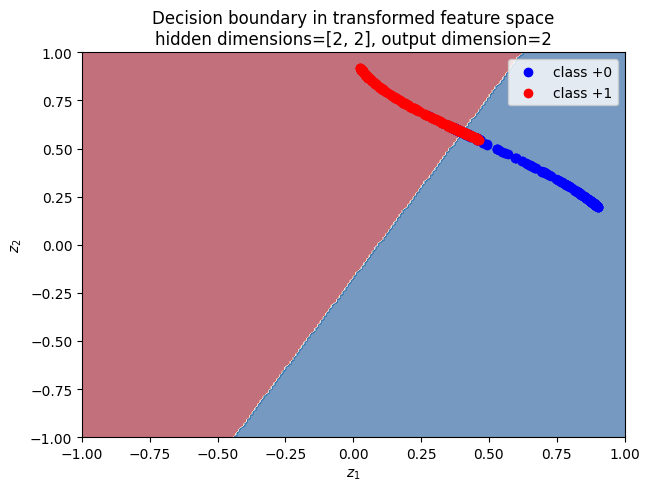

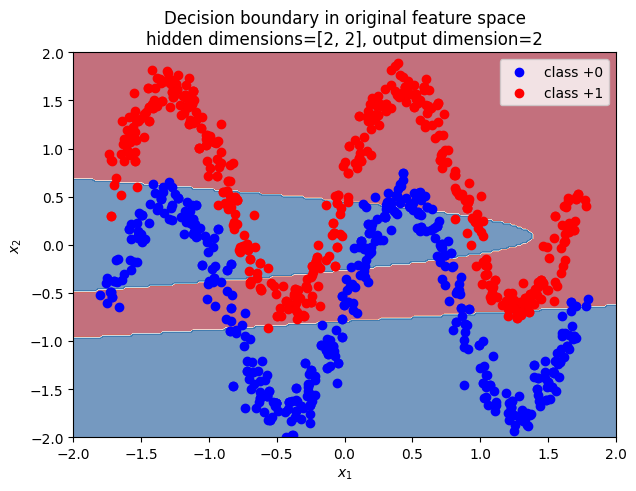

In [ ]:
data = load_dataset("sinusoids.pkl")
X_train = data["X_train"]
y_train = data["y_train"]
X_valid = data["X_valid"]
y_valid = data["y_valid"]

n, d = X_train.shape
k = len(np.unique(y_train))

Y_train = np.stack([1 - y_train, y_train], axis=1).astype(np.uint)

fig, ax = plt.subplots()
for c, color in [(0, "b"), (1, "r")]:
    in_c = y_train == c
    ax.scatter(X_train[in_c, 0], X_train[in_c, 1], color=color, label=f"class {c}")
ax.set_title("Sinusoid data, non-convex but separable.")
plt.show(fig)

X_train_standardized, mu, sigma = standardize_cols(X_train)
X_valid_standardized, _, _ = standardize_cols(X_valid, mu, sigma)

for hidden_feature_dims in [[4], [2], [2, 2]]:
    # We're running this several times, for different encoder architectures.
    output_dim = 2
    layer_sizes = [d, *hidden_feature_dims, output_dim]

    title = (
        f"hidden dimensions={hidden_feature_dims}, output dimension={output_dim}"
    )
    fn_suffix = f"{hidden_feature_dims}_{output_dim}"
    print("\nRunning with " + title)

    # for reproducibility of the solution
    np.random.seed(10)

    best_err_valid = np.inf
    best_model = None
    for seed in range(20):  # "grid search over random seeds"
        # First, initialize an encoder and a predictor
        encoder = NonLinearEncoderMultiLayer(layer_sizes)
        predictor = LinearModelMultiOutput(output_dim, k)
        fun_obj = MLPLogisticRegressionLossL2(encoder, predictor, 0.0)
        optimizer = GradientDescentLineSearch()
        model = NeuralNet(
            fun_obj, optimizer, encoder, predictor, classifier_yes=True
        )
        for _ in range(10):
            # "continual warm-start with resets":
            # one brute-force method to fight NP-hard problems!
            # calling fit() will reset the optimizer state,
            # but the encoder and predictor's parameters will stay intact.
            model.fit(X_train_standardized, Y_train)

            # Comput training error
            y_hat = model.predict(X_train_standardized)
            err_train = np.mean(y_hat != y_train)

            # Compute validation error
            y_hat = model.predict(X_valid_standardized)
            err_valid = np.mean(y_hat != y_valid)

            if err_valid < best_err_valid:
                best_err_valid = err_valid
                best_model = model

                # print("Training error = ", err_train)
                # print("Validation error     = ", err_valid)

    # Visualize learned features
    Z_train, _ = best_model.encode(X_train_standardized)

    fig, ax = plt.subplots()
    for c, color in [(0, "b"), (1, "r")]:
        in_c = y_train == c
        ax.scatter(
            X_train[in_c, 0], X_train[in_c, 1], color=color, label=f"class {c}"
        )
    ax.set_xlabel("$z_{1}$")
    ax.set_ylabel("$z_{2}$")
    ax.set_title("Learned features of sinusoid data\n" + title)
    plt.show(fig)

    fig, ax = plt.subplots()
    plot_classifier(best_model.predictor, Z_train, y_train, need_argmax=True, ax=ax)
    ax.set_xlabel("$z_{1}$")
    ax.set_ylabel("$z_{2}$")
    ax.set_title("Decision boundary in transformed feature space\n" + title)
    plt.show(fig)

    fig, ax = plt.subplots()
    plot_classifier(best_model, X_train_standardized, y_train, ax=ax)
    ax.set_xlabel("$x_{1}$")
    ax.set_ylabel("$x_{2}$")
    ax.set_title("Decision boundary in original feature space\n" + title)
    plt.show(fig)

# Principal Component Analysis (PCA) and Robust PCA

Implement Principal Component Analysis (PCA) for dimensionality reduction and explore Robust PCA for computer vision applications like background subtraction.`data/` contains `animals.pkl` and highway video frames.
* **`animals.pkl`**: includes 101 different types of zoo animals with 18 classification target

Code used in this notebook:
* `encoders.py` (PCAEncoder implementation using SVD)
* `fun_obj.py` (Loss functions for Robust PCA using smooth L1 approximation)
* `utils.py` (Data loading and standardization)




## What I built (quick summary)

### 1) PCA by Hand
- Manual Projection: Centered a 5x3 matrix and derived the first principal component vector $[1, -2, 1]^T$.
- Loss Calculation: Verified projection accuracy by calculating L2 reconstruction loss.

### 2) Dimensionality Reduction for Visualization
- High-to-Low mapping: Reduced an 85-dimensional "Animals" dataset to 2 principal components to visualize species clustering.
- Information Capture: Used the Frobenius norm to determine that 5 PCs are needed to explain >50% of the variance.

### 3) Robust PCA for Background Subtraction
- L1-Norm Approximation: Implemented a "multi-quadric" smooth approximation to handle non-differentiable L1 losses.
- Foreground Detection: Used the robustness of L1 to outliers to separate moving cars from a static highway background.

---
Running this notebook



## 1) Principal Component Analysis by Hand

I performed a manual calculation on a 5x3 dataset to understand the mechanics of data centering and projection onto the first Principal Component (PC).

### Step 1: Centering and Normalizing
After centering the matrix $X_c$ by subtracting column means, I identified the first PC $W$ by normalizing the common direction vector $[1, -2, 1]^T$:
$$W = \frac{1}{\sqrt{6}} \begin{bmatrix} 1 \\ -2 \\ 1 \end{bmatrix}$$

### Step 2: Reconstruction Loss
Reconstruction loss measures the error introduced by projecting a $d$-dimensional point onto a $k$-dimensional subspace.
- For point $(2.5, -3, 2.5)$, the loss is **0** (perfect alignment).
- For point $(1, -3, 2)$, the loss is **11/6** ($\approx 1.83$).

## 2) High-Dimensional Visualization (Animals Dataset)

Projecting 85 binary traits onto 2 Principal Components allows us to visualize how animals relate to one another based on latent features like "furry" or "grazer".

### Variance Explained
PCA is a trade-off between simplicity and information. For the animal dataset:
- **k=2 Components**: Explains **30.19%** of the variance.
- **k=5 Components**: Required to explain at least **50%** of the variance.

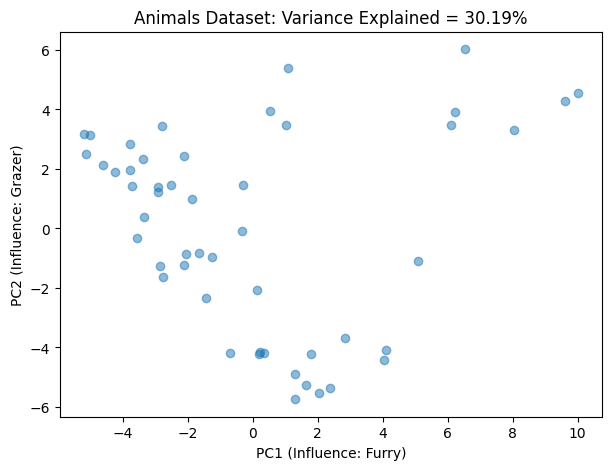

In [ ]:
data = load_dataset("animals.pkl")
X_std, mu, sigma = standardize_cols(data["X"])

encoder = PCAEncoder(k=2)
encoder.fit(X_std)
Z = encoder.encode(X_std)

plt.scatter(Z[:, 0], Z[:, 1], alpha=0.5)
plt.xlabel("PC1 (Influence: Furry)")
plt.ylabel("PC2 (Influence: Grazer)")
plt.title("Animals Dataset: Variance Explained = 30.19%")
plt.show()

## 3) Robust PCA for Background Subtraction

Standard PCA (L2) is sensitive to outliers. In a video of a highway, moving cars are "outliers" relative to the static road. Robust PCA uses an L1-norm loss to ensure the principal components capture the consistent background scenery while ignoring transient foreground objects.

### Visual Comparison: Regular PCA vs. Robust PCA
In regular PCA, the background reconstruction often looks "ghostly" because the model tries to average the cars into the background pixels. In Robust PCA, the background is significantly cleaner because the L1 loss allows the model to ignore the sparse outliers (cars).

### Smooth L1 Approximation
Since the L1 norm is non-differentiable at zero, I implemented a smooth **multi-quadric approximation**:
$$|\alpha| \approx \sqrt{\alpha^2 + \epsilon}$$

This allows the use of gradient-based optimization to solve for factors $Z$ and $W$.

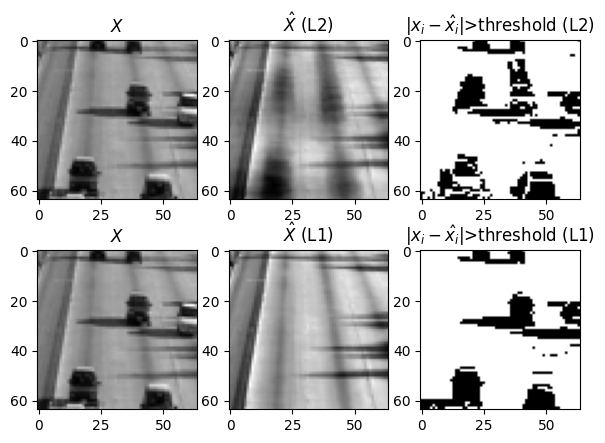

In [ ]:
X_train = load_dataset("highway.pkl")["X"].astype(float) / 255.0
n, d = X_train.shape
h, w = 64, 64  # height and width of each image
k = 5  # number of PCs
threshold = 0.1  # threshold for being considered "foreground"

# PCA with SVD
model = PCAEncoder(k)
model.fit(X_train)
Z = model.encode(X_train)
X_hat = model.decode(Z)

# TODO: Implement function objects for robust PCA in fun_obj.py
fun_obj_w = RobustPCAFactorsLoss(1e-6)
fun_obj_z = RobustPCAFeaturesLoss(1e-6)
optimizer_w = GradientDescentLineSearch(max_evals=100, verbose=False)
optimizer_z = GradientDescentLineSearch(max_evals=100, verbose=False)
model = LinearEncoderGradient(k, fun_obj_w, fun_obj_z, optimizer_w, optimizer_z)
model.fit(X_train)
Z_alt = model.encode(X_train)
X_hat_alt = model.decode(Z_alt)

for i in range(1):
    fig, ax = plt.subplots(2, 3)
    ax[0, 0].set_title("$X$")
    ax[0, 0].imshow(X_train[i].reshape(h, w).T, cmap="gray")

    ax[0, 1].set_title(r"$\hat{X}$ (L2)")
    ax[0, 1].imshow(X_hat[i].reshape(h, w).T, cmap="gray")

    ax[0, 2].set_title(r"$|x_i-\hat{x_i}|$>threshold (L2)")
    ax[0, 2].imshow(
        (np.abs(X_train[i] - X_hat[i]) < threshold).reshape(h, w).T, cmap="gray"
    )

    ax[1, 0].set_title("$X$")
    ax[1, 0].imshow(X_train[i].reshape(h, w).T, cmap="gray")

    ax[1, 1].set_title(r"$\hat{X}$ (L1)")
    ax[1, 1].imshow(X_hat_alt[i].reshape(h, w).T, cmap="gray")

    ax[1, 2].set_title(r"$|x_i-\hat{x_i}|$>threshold (L1)")
    ax[1, 2].imshow(
        (np.abs(X_train[i] - X_hat_alt[i]) < threshold).reshape(h, w).T, cmap="gray"
    )

    plt.show(fig)